In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0" # using the first gpu, for most cases, you wouldn't need to change it.
import scanpy as sc
import numpy as np
import pandas as pd
import anndata
import cupy as cp
import cupyx as cpx
import time
import rapids_singlecell as rsc
from rapids_singlecell.cunnData import cunnData
from tqdm.auto import tqdm, trange
import warnings
warnings.filterwarnings("ignore")
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator
rmm.reinitialize(
    managed_memory=True, # Allows oversubscription
    pool_allocator=True, # default is False
    devices=0, # GPU device IDs to register. By default registers only GPU 0.
)

cp.cuda.set_allocator(rmm_cupy_allocator)

In [2]:
#optimize resolution
from sknetwork.clustering import Louvain, get_modularity
from sknetwork.linalg import normalize
from sknetwork.utils import get_membership
from sknetwork.visualization import visualize_graph, visualize_bigraph
import matplotlib.pyplot as plt
from tqdm import tqdm

In [19]:
df = pd.read_csv("/n/holylfs06/LABS/buenrostro_lab/Users/rsavage/minimorf/final_terra/umap/cistopic_matrices/celltopic100.txt", sep="\t")
barcode = df['cell']
df = df.iloc[:, 1:]
x = df.to_numpy()
x.shape
adata = anndata.AnnData(X=x)
rsc.utils.anndata_to_GPU(adata)

In [ ]:
res=list(np.arange(0, 1, 0.1))+list(np.arange(1, 3, 0.5))

results = []

for n_neighbors in tqdm([25,50,75,100]):

    rsc.pp.neighbors(adata, metric='cosine', n_neighbors=n_neighbors)
    mods=[]
    for i in res:
        rsc.tl.louvain(adata, resolution=i)
        row_labels=np.array(adata.obs['louvain']).astype(int)
        modularity=get_modularity(adata.obsp['connectivities'], labels=row_labels)
        mods.append(modularity)
        
        results.append({
            "n_neighbors": n_neighbors,
            "resolution": i,
            "modularity": modularity
        })
results_df = pd.DataFrame(results)


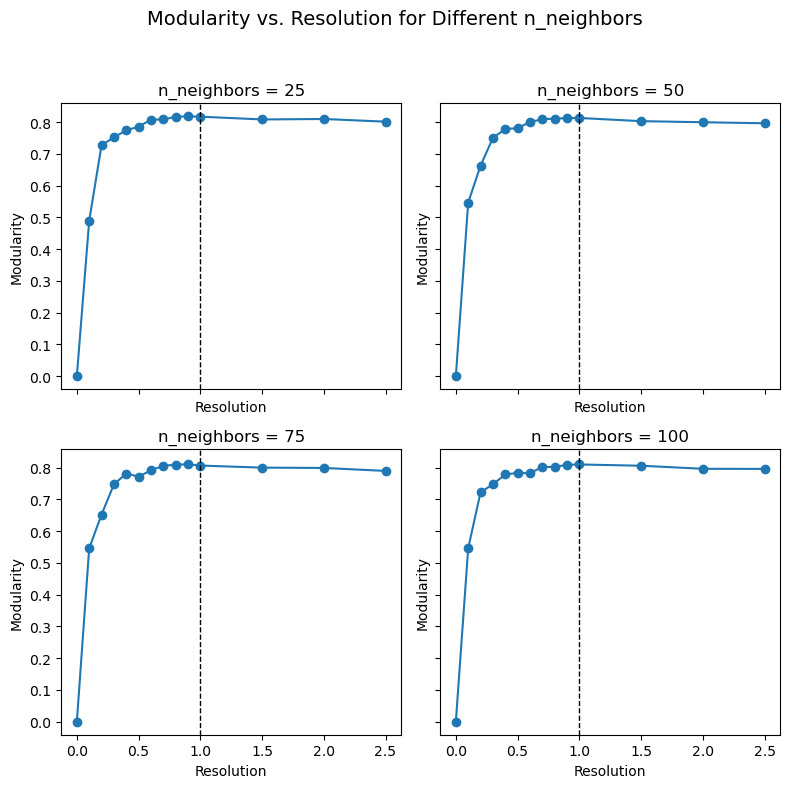

In [49]:
# Get unique values

n_neighbors_values = results_df['n_neighbors'].unique()

# Create 4 subplots (2 rows × 2 columns)
fig, axs = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Loop through each n_neighbors group
for idx, n in enumerate(n_neighbors_values):
    subset = results_df[results_df['n_neighbors'] == n]
    ax = axs[idx]
    ax.plot(subset['resolution'], subset['modularity'], marker='o')
    ax.axvline(x=1, color='black', linestyle='--', linewidth=1)

    ax.set_title(f'n_neighbors = {n}')
    ax.set_xlabel("Resolution")
    ax.set_ylabel("Modularity")

plt.suptitle("Modularity vs. Resolution for Different n_neighbors", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [20]:
n_neighbors=50
rsc.pp.neighbors(adata, metric='cosine', n_neighbors=n_neighbors)

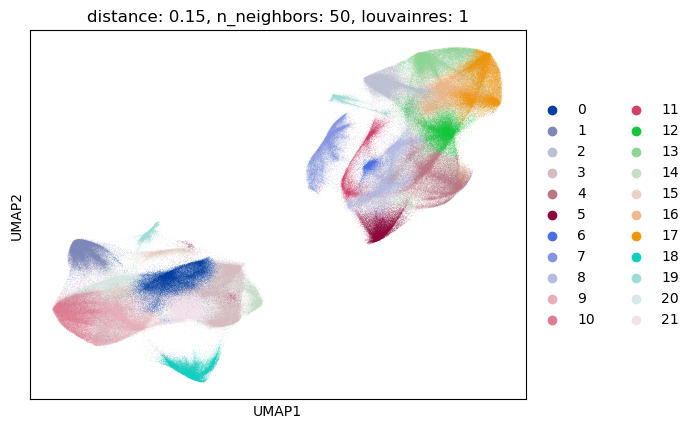

In [21]:
min_dist = 0.15 
louvainres = 1

# adjust your n_neighbors, metric, here
# adjust your min_dist here
rsc.tl.umap(adata, min_dist=min_dist, maxiter = 2000)
#sc.pl.umap(adata, ncols=1)
rsc.tl.louvain(adata, resolution=louvainres)
titlein = "distance: " + str(min_dist) + ", n_neighbors: " + str(n_neighbors) + ", louvainres: " + str(louvainres)
sc.pl.umap(adata, ncols=1, 
           color=['louvain'], 
           title = titlein)


In [23]:
# now save it
adata.obs['barcode'] = barcode.values
adata.obs['umap_x'] = adata.obsm['X_umap'][:, 0]
adata.obs['umap_y'] = adata.obsm['X_umap'][:, 1]
# This stores umap coord into tsv format.
adata.obs.to_csv("./umapcoor_leiden.100topics.50nn.0.15dist.txt", sep='\t', index=False)

In [24]:
# Finally, if you just want a row x n_neighbor table, this will achieve it.
coo_matrix = adata.obsp['distances'].tocoo()
row = coo_matrix.row
col = coo_matrix.col
mtx = [[] for i in range(len(adata))]
for r,c in zip(tqdm(row), col):
    mtx[r].append(c)


100%|██████████| 35115700/35115700 [00:11<00:00, 3155843.24it/s]


In [25]:
mtx = pd.DataFrame(mtx)
mtx.to_csv("knn.100topics.50nn.0.15dist.txt", sep='\t', index=False)

In [56]:
results_df.to_csv("louvain_modularity.csv", index=False)